In [1]:
# Using scanpy to generate synthetic dataset, and preprocess open source sequencing datasets
import scanpy as sc
import pandas as pd
import numpy as np
import pylab as plt

## ToggleSwitch

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:132: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


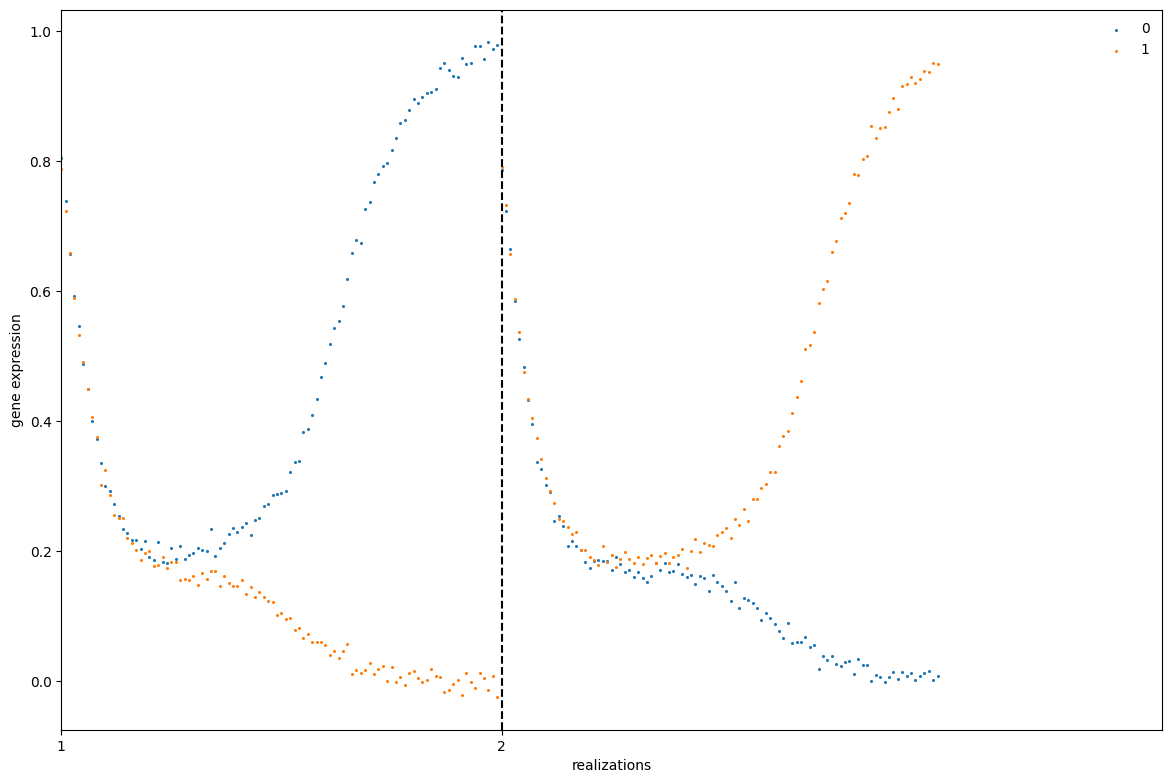

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


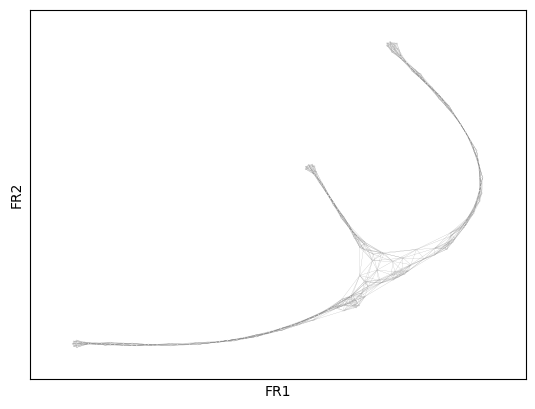

In [2]:
# ToggleSwitch
adata = sc.tl.sim('toggleswitch')
sc.pl.sim(adata)
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.draw_graph(adata)
sc.pl.draw_graph(adata, edges=True, size=4)

In [3]:
labels = ['root']+['inter1']*24+['branch1']*75+['inter2']*45+['branch2']*55
adata.obs['labels'] = pd.Categorical(labels)

In [4]:
expmat = pd.DataFrame({0:adata.X[:,0],1:adata.X[:,1]})
# expmat.to_csv('../Data/MHMDS-proj-data/Processed_data/ToggleSwitch.csv')
# np.savetxt('../Data/MHMDS-proj-data/Processed_data/FeatMat_ToggleSwitch.txt',adata.X)
metadata = pd.DataFrame({'labels':labels})
# metadata.to_csv('../Data/MHMDS-proj-data/Processed_data/ToggleSwitch_metadata.csv')

## krumsiek11

In [5]:
adata = sc.datasets.krumsiek11()

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
expmat = pd.DataFrame(adata.X,index = adata.obs_names,columns=adata.var_names)
# expmat.to_csv('../Data/MHMDS-proj-data/Processed_data/Krumsiek11.csv')
# np.savetxt('../Data/MHMDS-proj-data/Processed_data/FeatMat_Krumsiek11.txt',adata.X)
metadata = adata.obs
# metadata.to_csv('../Data/MHMDS-proj-data/Processed_data/Krumsiek11_metadata.csv')

## Paul

In [26]:
adata = sc.datasets.paul15()

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/datasets/_datasets.py:204: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['iroot'] = 840


In [27]:
metadata = adata.obs
# metadata.to_csv('../Data/MHMDS-proj-data/Processed_data/Paul_metadata.csv')

In [28]:
adata.X.shape

(2730, 3451)

In [29]:
sc.pp.recipe_zheng17(adata)
print(adata.X.shape)

(2730, 999)


In [30]:
expmat = pd.DataFrame(adata.X,index = adata.obs_names,columns=adata.var_names)
# expmat.to_csv('../Data/MHMDS-proj-data/Processed_data/Paul.csv')

In [31]:
# PCA on Paul data
sc.tl.pca(adata, n_comps=100,svd_solver="arpack")

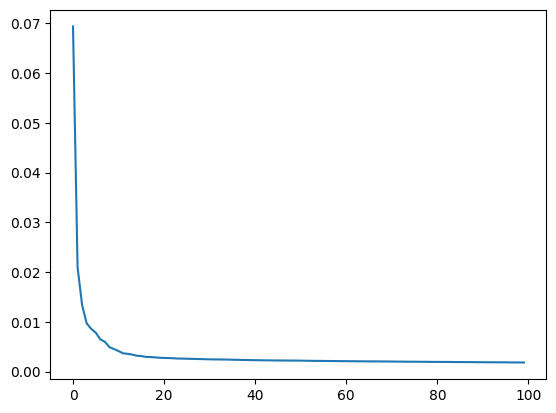

In [33]:
plt.plot(adata.uns['pca']['variance_ratio'])

In [34]:
# np.savetxt('../Data/MHMDS-proj-data/Processed_data/FeatMat_Paul_PCA100.txt',adata.obsm['X_pca'])
# np.savetxt('../Data/MHMDS-proj-data/Processed_data/FeatMat_Paul_PCA20.txt',adata.obsm['X_pca'])

## C. elegans

Note: We are not able to include the C. elegans count matrix itself due to constraint in file size in submission, but it was available here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE126954 

In [2]:
# from scipy.io import mmread

In [3]:
# load c elegan data
mydf3 = mmread('../Data/BenchmarkData/Celegan/GSE126954_gene_by_cell_count_matrix.txt').toarray()

In [4]:
mydf3.shape

(20222, 89701)

In [5]:
# load genes 
genes = pd.read_csv('../Data/BenchmarkData/Celegan/GSE126954_gene_annotation.csv')
metadata = pd.read_csv('../Data/BenchmarkData/Celegan/GSE126954_cell_annotation.csv',index_col=0)

In [43]:
# preprocessing
adata = sc.AnnData(mydf3.T)
adata.var_names = genes.gene_short_name
adata.obs = metadata
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=4)

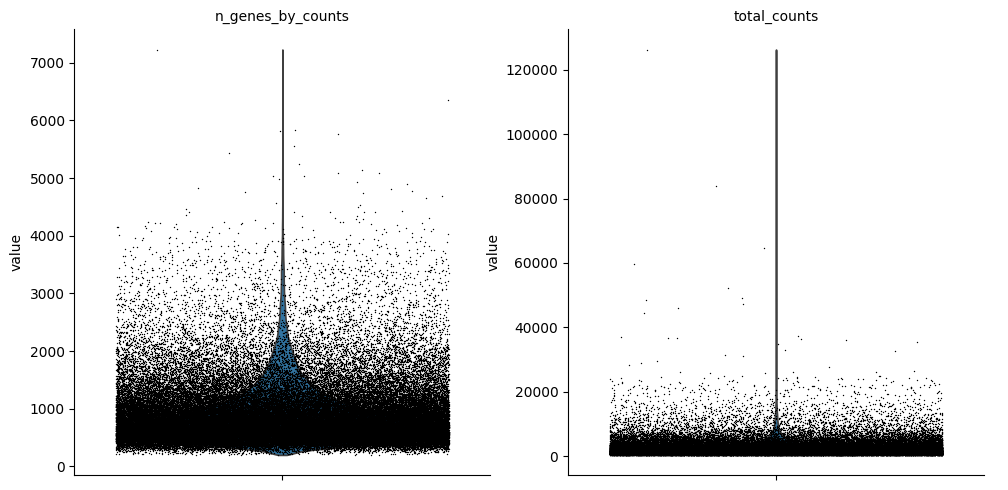

In [47]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)


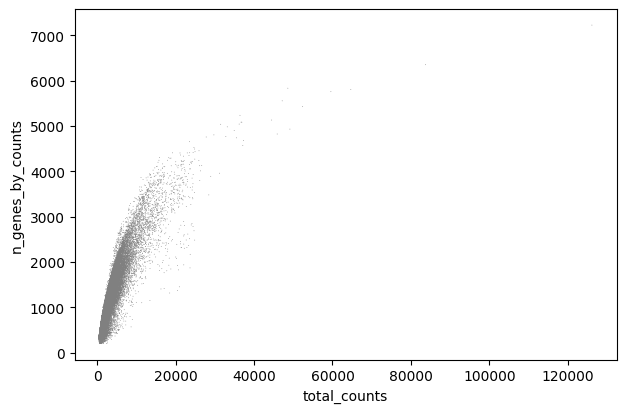

In [48]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [49]:
adata = adata[adata.obs.n_genes_by_counts < 4000, :]

In [50]:
sc.pp.normalize_total(adata, target_sum=1e4)

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [51]:
sc.pp.log1p(adata)

In [52]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

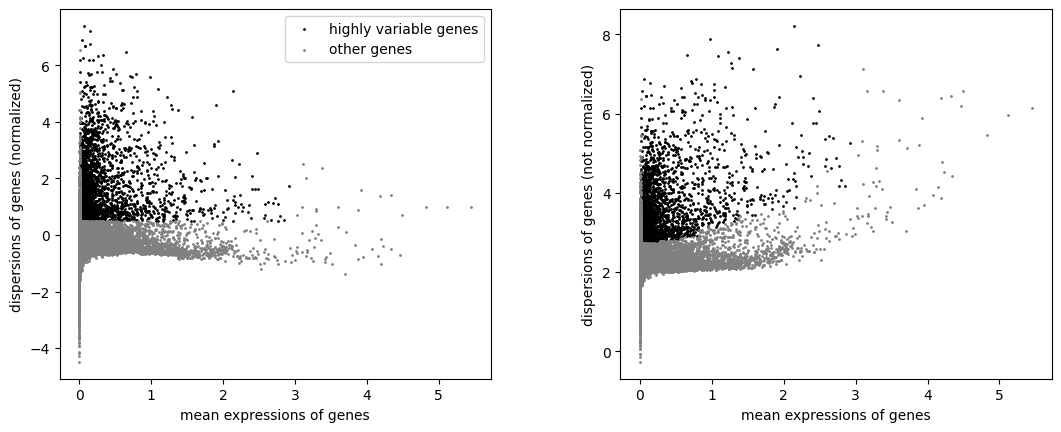

In [53]:
sc.pl.highly_variable_genes(adata)

In [54]:
adata.raw = adata

In [55]:
adata = adata[:, adata.var.highly_variable]

In [57]:
# select sub clusters and perform PCA
adata.X.shape

(89581, 2756)

In [64]:
adata_lineage = adata[adata.obs.lineage.str.startswith('ABpxp',na=False),:]

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:229: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = X_pca


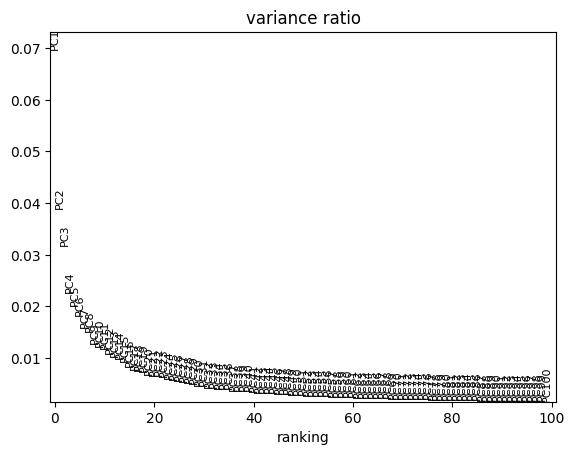

In [66]:
sc.tl.pca(adata_lineage, n_comps=100,svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_lineage,n_pcs=100)

In [67]:
# np.savetxt('../data/FeatMat_Celegans_PCA50_lineage_ABpxp/FeatMat_Celegans_PCA50_lineage_ABpxp.txt',adata_lineage.obsm['X_pca'][:,:50])
# adata_lineage.obs[['cell.type','cell.subtype','embryo.time','embryo.time.bin','lineage']].to_csv(
# '../data/metadata/Celegans_PCA50_lineage_ABpxp_metadata.csv')

In [ ]:
sc.tl.pca(adata, n_comps=100,svd_solver="arpack")

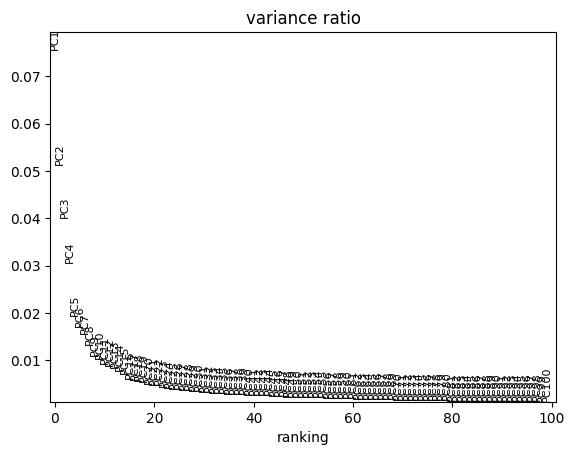

In [62]:
sc.pl.pca_variance_ratio(adata_lineage,n_pcs=40)

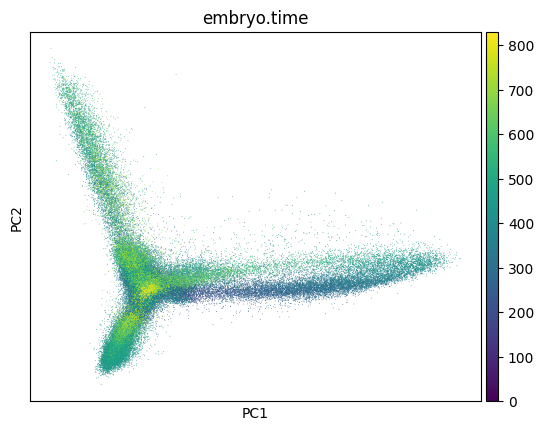

In [69]:
sc.pl.pca(adata, color="embryo.time")

/Users/mingchen/anaconda3/envs/scanpy-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


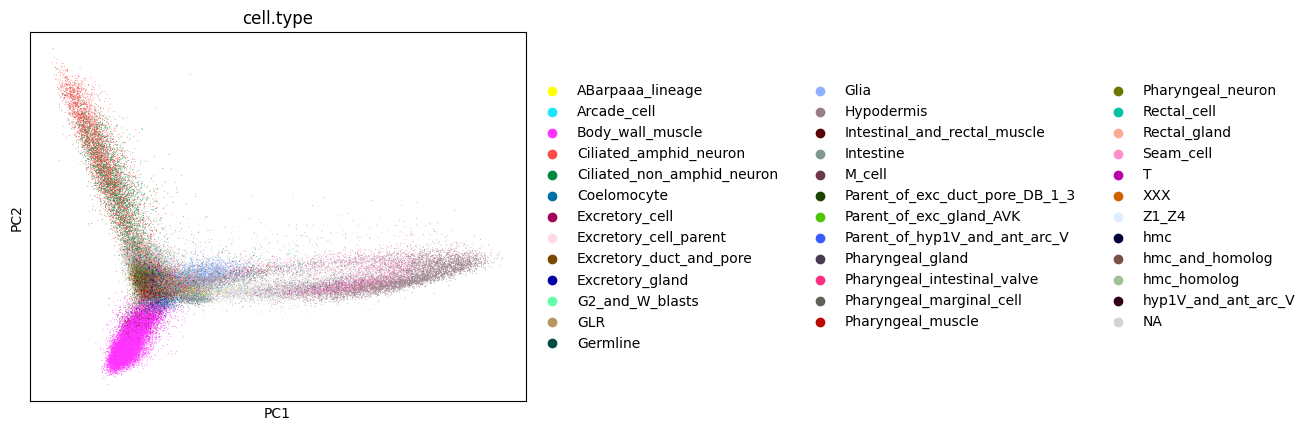

In [70]:
sc.pl.pca(adata, color="cell.type")

In [71]:
# filter for n genes >= 30
keep = np.sum(adata.X!=0,axis=1)>=30
print(sum(keep))

85333


In [91]:
# save PCA result
# np.savetxt('../data/FeatMat_Celegans_PCA100/FeatMat_Celegans_PCA100.txt',adata.obsm['X_pca'][keep])

In [93]:
# metatosave = adata.obs[['cell.type','cell.subtype','embryo.time','embryo.time.bin','lineage']].iloc[keep]
# metatosave.to_csv('../data/metadata/Celegans_PCA100_metadata.csv')